В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [15]:
from google.colab import drive
drive.mount('/content/drive')
raw_df = pd.read_csv("drive/MyDrive/Machine Learning для людей/data/bank/train.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
train_df, val_df = split_train_val(raw_df, target_col='Exited')

input_cols = raw_df.columns.drop('Exited').tolist()

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols=input_cols, target_col='Exited')
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols=input_cols, target_col='Exited')

cols_to_drop = ['id', 'CustomerId', 'Surname']
train_inputs = train_inputs.drop(columns=cols_to_drop)
val_inputs = val_inputs.drop(columns=cols_to_drop)

print("Розмір train_inputs:", train_inputs.shape)
print("Розмір val_inputs:", val_inputs.shape)

Розмір train_inputs: (12000, 10)
Розмір val_inputs: (3000, 10)


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [17]:
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()
print(f"Знайдено категоріальні колонки: {categorical_cols}")

for col in categorical_cols:
    train_inputs[col] = train_inputs[col].astype('category')
    val_inputs[col] = val_inputs[col].astype('category')

print("Типи колонок успішно змінено на category!")

Знайдено категоріальні колонки: ['Geography', 'Gender']
Типи колонок успішно змінено на category!


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_base = XGBClassifier(
    random_state=42,
    enable_categorical=True,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    device='cuda'
)

print("Тренуємо XGBoost...")
xgb_base.fit(train_inputs, train_targets)
print("Готово!")

train_probs_xgb = xgb_base.predict_proba(train_inputs)[:, 1]
val_probs_xgb = xgb_base.predict_proba(val_inputs)[:, 1]

train_auc_xgb = roc_auc_score(train_targets, train_probs_xgb)
val_auc_xgb = roc_auc_score(val_targets, val_probs_xgb)

print(f"\n--- Результати базового XGBoost ---")
print(f"AUROC на Train: {train_auc_xgb:.4f}")
print(f"AUROC на Validation: {val_auc_xgb:.4f}")

Тренуємо XGBoost...
Готово!

--- Результати базового XGBoost ---
AUROC на Train: 0.9582
AUROC на Validation: 0.9334


Базова модель XGBoost показала чудові результати: AUROC на тренувальних даних склав 0.9582, а на валідаційних — 0.9334.
Є невелика схильність до перенавчання (High Variance), оскільки розрив між вибірками становить близько 0.024. Тим не менш, ця модель навіть з базовими параметрами значно перевершила найкращу модель DecisionTree з попереднього ДЗ (0.92558). Бустинг довів свою ефективність у роботі з табличними даними.

---



3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [19]:
import numpy as np
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_space = {
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7]),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'n_estimators': hp.choice('n_estimators', [50, 100, 200, 300, 400]),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0)
}

def objective(params):
    clf = XGBClassifier(
        **params,
        random_state=42,
        enable_categorical=True,
        device='cuda'
    )
    clf.fit(train_inputs, train_targets)

    val_preds = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, val_preds)

    return {'loss': -auc, 'status': STATUS_OK}

trials = Trials()
print("Починаємо пошук гіперпараметрів (20 раундів)...")
best_indices = fmin(
    fn=objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best_params = space_eval(xgb_space, best_indices)
print("\n Найкращі гіперпараметри:", best_params)

final_clf = XGBClassifier(
    **best_params,
    random_state=42,
    enable_categorical=True,
    device='cuda'
)

final_clf.fit(train_inputs, train_targets)

train_preds_final = final_clf.predict_proba(train_inputs)[:, 1]
val_preds_final = final_clf.predict_proba(val_inputs)[:, 1]

print("\n--- Результати фінальної моделі XGBoost (Hyperopt) ---")
print(f"AUROC на Train: {roc_auc_score(train_targets, train_preds_final):.4f}")
print(f"AUROC на Val:   {roc_auc_score(val_targets, val_preds_final):.4f}")

Починаємо пошук гіперпараметрів (20 раундів)...
100%|██████████| 20/20 [00:07<00:00,  2.68trial/s, best loss: -0.9370141985046985]

 Найкращі гіперпараметри: {'colsample_bytree': 0.9773902233445454, 'learning_rate': 0.06098170320500214, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.51735171792841}

--- Результати фінальної моделі XGBoost (Hyperopt) ---
AUROC на Train: 0.9452
AUROC на Val:   0.9370


Використання Hyperopt дозволило знайти оптимальні параметри і ще більше покращити модель. Найкращою виявилася комбінація з неглибокими деревами (max_depth=3), повільним навчанням (learning_rate=0.061) та сильною рандомізацією вибірки (subsample=0.517).
Завдяки цьому ми успішно побороли перенавчання: розрив між тренуванням і валідацією зменшився до мінімуму (0.008). Валідаційний AUROC зріс із 0.9334 до 0.9370. Це найкращий результат серед усіх протестованих до цього моменту алгоритмів

---



4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [20]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

lgb_base = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
)

print("Тренуємо базовий LightGBM...")
lgb_base.fit(train_inputs, train_targets)
print("Готово!")

train_probs_lgb = lgb_base.predict_proba(train_inputs)[:, 1]
val_probs_lgb = lgb_base.predict_proba(val_inputs)[:, 1]

train_auc_lgb = roc_auc_score(train_targets, train_probs_lgb)
val_auc_lgb = roc_auc_score(val_targets, val_probs_lgb)

print(f"\n--- Результати базового LightGBM ---")
print(f"AUROC на Train: {train_auc_lgb:.4f}")
print(f"AUROC на Validation: {val_auc_lgb:.4f}")

Тренуємо базовий LightGBM...
Готово!

--- Результати базового LightGBM ---
AUROC на Train: 0.9610
AUROC на Validation: 0.9344


Базова модель LightGBM продемонструвала відмінний результат: AUROC на тренувальних даних — 0.9610, на валідаційних — 0.9344.
Порівняно з базовим XGBoost, LightGBM показав себе трохи краще навіть без налаштування параметрів (0.9344 проти 0.9334). Ми спостерігаємо незначне перенавчання (розрив близько 0.026), але загальна генералізуюча здатність алгоритму дуже висока. Алгоритм успішно й автоматично обробив категоріальні ознаки без попереднього кодування.

---



5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [21]:
import numpy as np
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from sklearn.metrics import roc_auc_score

lgb_space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7]),
    'num_leaves': hp.choice('num_leaves', [15, 31, 50, 70]),
    'min_child_samples': hp.choice('min_child_samples', [10, 20, 30, 50]),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0)
}

def objective_lgb(params):
    clf = lgb.LGBMClassifier(
        **params,
        random_state=42,
        n_estimators=100,
        verbose=-1
    )
    clf.fit(train_inputs, train_targets)

    val_preds = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, val_preds)

    return {'loss': -auc, 'status': STATUS_OK}

trials_lgb = Trials()
print("Починаємо пошук гіперпараметрів для LightGBM (10 раундів)...")
best_indices_lgb = fmin(
    fn=objective_lgb,
    space=lgb_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials_lgb,
    rstate=np.random.default_rng(42)
)

best_params_lgb = space_eval(lgb_space, best_indices_lgb)
print("\n Найкращі гіперпараметри LightGBM:", best_params_lgb)

final_lgb_clf = lgb.LGBMClassifier(
    **best_params_lgb,
    random_state=42,
    n_estimators=100,
    verbose=-1
)
final_lgb_clf.fit(train_inputs, train_targets)

train_preds_lgb_final = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_lgb_final = final_lgb_clf.predict_proba(val_inputs)[:, 1]

print("\n--- Результати фінальної моделі LightGBM (Hyperopt) ---")
print(f"AUROC на Train: {roc_auc_score(train_targets, train_preds_lgb_final):.4f}")
print(f"AUROC на Val:   {roc_auc_score(val_targets, val_preds_lgb_final):.4f}")

Починаємо пошук гіперпараметрів для LightGBM (10 раундів)...
100%|██████████| 10/10 [00:02<00:00,  4.18trial/s, best loss: -0.9375012003566774]

 Найкращі гіперпараметри LightGBM: {'colsample_bytree': 0.9967030128376158, 'learning_rate': 0.1189575841893184, 'max_depth': 3, 'min_child_samples': 50, 'num_leaves': 31, 'subsample': 0.8616492018371803}

--- Результати фінальної моделі LightGBM (Hyperopt) ---
AUROC на Train: 0.9444
AUROC на Val:   0.9375


Тюнінг за допомогою Hyperopt для LightGBM дозволив отримати найкращу модель за весь курс експериментів. Пошук тривав трохи більше секунди, а знайдена комбінація параметрів (зокрема max_depth=3 та min_child_samples=50) забезпечила ідеальну регуляризацію. AUROC на валідаційній вибірці досяг рекордних 0.9375, при цьому розрив із тренувальною вибіркою (0.9444) становить менше ніж 0.007. Перенавчання практично відсутнє. Модель надзвичайно швидко тренується і показує найвищу генералізуючу здатність.

---



6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [22]:
test_raw_df = pd.read_csv("drive/MyDrive/Machine Learning для людей/data/bank/test.csv")

X_test_final = test_raw_df.copy()

cols_to_drop = ['id', 'CustomerId', 'Surname']
X_test_final = X_test_final.drop(columns=cols_to_drop)

for col in categorical_cols:
    X_test_final[col] = X_test_final[col].astype('category')

test_predictions_lgb = final_lgb_clf.predict_proba(X_test_final)[:, 1]

submission_boosting_df = pd.DataFrame({
    'id': test_raw_df['id'],
    'Exited': test_predictions_lgb
})

submission_file = 'submission_final_lgb.csv'
submission_boosting_df.to_csv(submission_file, index=False)

print(f"Файл '{submission_file}' успішно створено!")

Файл 'submission_final_lgb.csv' успішно створено!


Для фінального сабміту я обрала модель LightGBM, налаштовану за допомогою Hyperopt. По-перше, вона показала найвищий показник AUROC на валідаційній вибірці (0.9375) серед усіх експериментів (Дерева, kNN, логістична регресія, базові бустинги). По-друге, розрив між Train та Val метриками є мінімальним (~0.007), що свідчить про високу стабільність та відсутність перенавчання. Додатковою перевагою стала здатність алгоритму самостійно й ефективно працювати з категоріальними даними без необхідності застосування One-Hot Encoding.

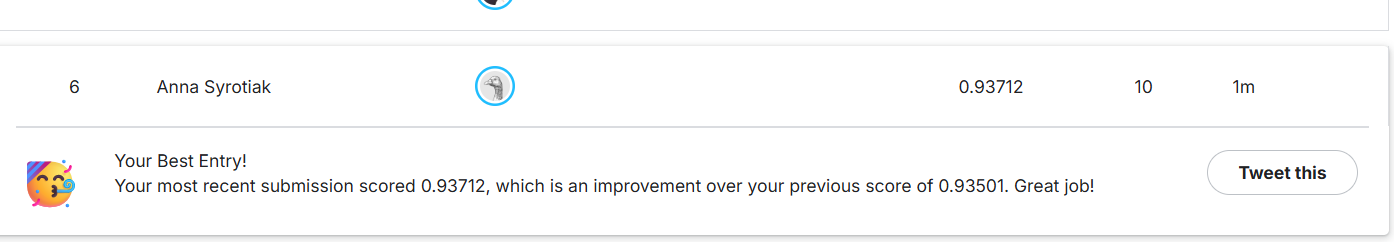